<a href="https://colab.research.google.com/github/PhiWhyyy/ecommerce-product-analytics/blob/main/RetailExperiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
pip install pandas openpyxl matplotlib seaborn

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load both sheets and combine
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
df = pd.concat([df1, df2], ignore_index=True)

# First look
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           floa

In [14]:
# Drop rows with no Customer ID (can't track behaviour without it)
df = df.dropna(subset=['Customer ID'])

# Remove cancellations (invoices starting with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove negative quantities and prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# Parse date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Year'] = df['InvoiceDate'].dt.year

print(f"Clean dataset: {df.shape[0]} rows, {df['Customer ID'].nunique()} unique customers")

Clean dataset: 805549 rows, 5878 unique customers


In [16]:
# 1. Monthly Revenue
monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

# 2. Monthly Active Users (unique customers per month)
mau = df.groupby('Month')['Customer ID'].nunique().reset_index()
mau.columns = ['Month', 'MAU']
mau['Month'] = mau['Month'].astype(str)

# 3. Average Order Value (AOV)
order_value = df.groupby('Invoice')['Revenue'].sum().reset_index()
aov = order_value['Revenue'].mean()
print(f"Average Order Value: £{aov:.2f}")

# 4. Orders per customer
orders_per_customer = df.groupby('Customer ID')['Invoice'].nunique()
print(f"Avg orders per customer: {orders_per_customer.mean():.2f}")

# 5. Top countries by revenue
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(
    ascending=False).head(10)
print(top_countries)

Average Order Value: £479.95
Avg orders per customer: 6.29
Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64


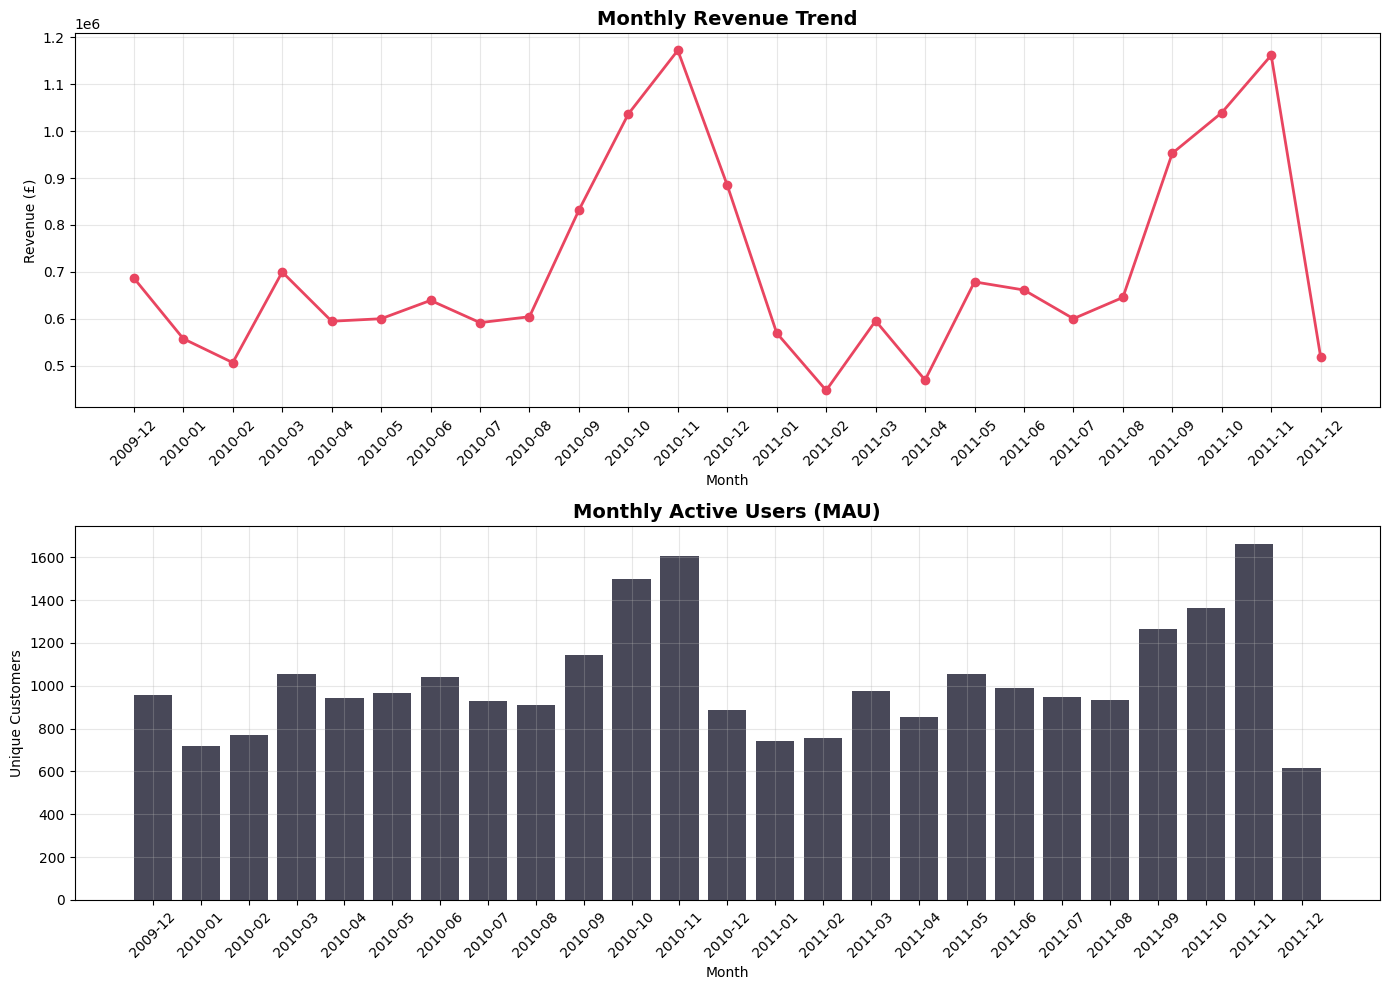

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Revenue trend
axes[0].plot(monthly_revenue['Month'],
             monthly_revenue['Revenue'],
             marker='o', color='#E94560', linewidth=2)
axes[0].set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

# MAU trend
mau_merged = mau.copy()
axes[1].bar(mau_merged['Month'],
            mau_merged['MAU'],
            color='#1A1A2E', alpha=0.8)
axes[1].set_title('Monthly Active Users (MAU)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Unique Customers')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase1_metrics.png', dpi=150, bbox_inches='tight')
plt.show()